In [2]:
# 导入必要的库
import matplotlib as mpl
import matplotlib.pyplot as plt
# 在Jupyter notebook中内联显示图表
%matplotlib inline  
import numpy as np
import sklearn
import pandas as pd
import os
import sys
import time
from tqdm.auto import tqdm  # 进度条库
import torch
import torch.nn as nn
import torch.nn.functional as F

# 打印Python版本信息
print(sys.version_info)

# 打印各个库的版本信息
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置设备：如果有GPU则使用GPU，否则使用CPU
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)


sys.version_info(major=3, minor=12, micro=12, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.3.5
pandas 3.0.0
sklearn 1.8.0
torch 2.10.0+cu130
cuda:0


# 数据预处理

In [3]:
# INSERT_YOUR_CODE
from torchvision import datasets, transforms
import os

# 设置数据目录
data_dir = './archive/'

# 定义预处理: resize到128x128, 转为tensor
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4363, 0.4328, 0.3291], std=[0.2427, 0.2382, 0.2413])
])

# 读取训练集和测试集
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'training'), transform=transform)
test_dataset = datasets.ImageFolder(root=os.path.join(data_dir, 'validation'), transform=transform)

# 获取类别名（方便后续显示标签）
class_names = train_dataset.classes
class_names

['n0', 'n1', 'n2', 'n3', 'n4', 'n5', 'n6', 'n7', 'n8', 'n9']

In [4]:
len(train_dataset)

1097

In [5]:
train_dataset[0][0].shape #特征

torch.Size([3, 128, 128])

In [6]:
train_dataset[0][1] #标签

0

In [7]:
len(test_dataset)

272

In [8]:
# INSERT_YOUR_CODE

# from torch.utils.data import DataLoader
# import torch

# loader = DataLoader(train_dataset, batch_size=64, shuffle=False, num_workers=2)

# mean = torch.zeros(3)
# std = torch.zeros(3)
# n_pixels = 0

# for images, _ in loader:  # images: [B, 3, 128, 128]
#     batch_pixels = images.numel() // 3  # total pixels per channel
#     mean += images.sum(dim=[0, 2, 3])
#     std  += (images ** 2).sum(dim=[0, 2, 3])
#     n_pixels += batch_pixels

# mean /= n_pixels
# std = torch.sqrt(std / n_pixels - mean ** 2)

# print("按通道均值:", mean)
# print("按通道标准差:", std)



In [9]:
from torch.utils.data import DataLoader

# 创建训练集和验证集的DataLoader
batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,  # 训练时打乱数据
    num_workers=2  # 使用多进程加载数据
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,  # 测试时不需要打乱
    num_workers=2
)

print(f"训练集DataLoader批次数: {len(train_loader)}")
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个批次的数据
train_iter = iter(train_loader)
batch_images, batch_labels = next(train_iter)
print(f"批次图像张量形状: {batch_images.shape}")
print(f"批次标签张量形状: {batch_labels.shape}")
print(batch_labels)

训练集DataLoader批次数: 35
测试集DataLoader批次数: 9
每个批次大小: 32
批次图像张量形状: torch.Size([32, 3, 128, 128])
批次标签张量形状: torch.Size([32])
tensor([6, 5, 2, 4, 0, 6, 7, 5, 4, 7, 9, 7, 4, 8, 3, 9, 6, 3, 4, 7, 1, 7, 1, 5,
        5, 0, 4, 5, 3, 2, 8, 8])


# 搭建模型

In [10]:
from torchvision.models import resnet50

class ResNet50(nn.Module):
    def __init__(self, num_classes=10, frozen=True):
        super().__init__()
        # 下载预训练权重
        self.model = resnet50(weights='IMAGENET1K_V2')
        # 冻结所有参数
        if frozen:
            for param in self.model.parameters():
                param.requires_grad = False
        # 对layer4进行解冻
        for param in self.model.layer4.parameters():
            param.requires_grad = True
        # 替换最后一层fc为10分类
        in_features = self.model.fc.in_features #2048
        self.model.fc = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        return self.model(x)

model=ResNet50()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\dell/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:25<00:00, 4.03MB/s]


In [11]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确
import torch

dummy_input = torch.randn(32, 3, 128, 128) 
output = model(dummy_input) #前向传播/前向计算/正向传播
print(f"Output shape: {output.shape}")


Output shape: torch.Size([32, 10])


In [12]:
# 输出model每一层的参数量
total_params = 0  # 初始化总参数量为0
print("各层参数量统计：")  # 打印参数统计表头
for name, param in model.named_parameters():  # 遍历模型中所有需要优化的参数
    if param.requires_grad:  # 只有需要梯度更新的参数才统计
        num_params = param.numel()  # 计算当前参数的元素总数
        total_params += num_params  # 更新总参数量
        print(f"{name}: {num_params}")  # 输出当前层的参数量
print(f"模型总参数量: {total_params}")  # 输出模型总参数量


各层参数量统计：
model.layer4.0.conv1.weight: 524288
model.layer4.0.bn1.weight: 512
model.layer4.0.bn1.bias: 512
model.layer4.0.conv2.weight: 2359296
model.layer4.0.bn2.weight: 512
model.layer4.0.bn2.bias: 512
model.layer4.0.conv3.weight: 1048576
model.layer4.0.bn3.weight: 2048
model.layer4.0.bn3.bias: 2048
model.layer4.0.downsample.0.weight: 2097152
model.layer4.0.downsample.1.weight: 2048
model.layer4.0.downsample.1.bias: 2048
model.layer4.1.conv1.weight: 1048576
model.layer4.1.bn1.weight: 512
model.layer4.1.bn1.bias: 512
model.layer4.1.conv2.weight: 2359296
model.layer4.1.bn2.weight: 512
model.layer4.1.bn2.bias: 512
model.layer4.1.conv3.weight: 1048576
model.layer4.1.bn3.weight: 2048
model.layer4.1.bn3.bias: 2048
model.layer4.2.conv1.weight: 1048576
model.layer4.2.bn1.weight: 512
model.layer4.2.bn1.bias: 512
model.layer4.2.conv2.weight: 2359296
model.layer4.2.bn2.weight: 512
model.layer4.2.bn2.bias: 512
model.layer4.2.conv3.weight: 1048576
model.layer4.2.bn3.weight: 2048
model.layer4.2.bn3.

# 训练

In [13]:
import torch.nn as nn
import torch.optim as optim

# 初始化交叉熵损失函数，内部会做softmax
criterion = nn.CrossEntropyLoss()

# 初始化优化器（这里选用Adam，也可以使用SGD等）
optimizer = optim.SGD(model.parameters(), lr=0.001)


In [14]:
import trainmodule_train
# 假设train_loader和val_loader已定义，device已经设为"cuda"或"cpu"
trainer = trainmodule_train.Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    eval_step=100
)

# 设定训练轮数
num_epochs = 20

# 开始训练
trainer.train(num_epochs)


Epoch [1/20]  Train Loss: 2.2883  Train Acc: 0.1158
Epoch [2/20]  Train Loss: 2.2127  Train Acc: 0.2215
[Step 100] Val Loss: 2.1068 Val Acc: 0.4559
Epoch [3/20]  Train Loss: 2.1364  Train Acc: 0.3820
Epoch [4/20]  Train Loss: 2.0651  Train Acc: 0.5087
Epoch [5/20]  Train Loss: 1.9947  Train Acc: 0.6108
[Step 200] Val Loss: 1.9065 Val Acc: 0.7537
Epoch [6/20]  Train Loss: 1.9069  Train Acc: 0.6928
Epoch [7/20]  Train Loss: 1.8365  Train Acc: 0.7256
Epoch [8/20]  Train Loss: 1.7529  Train Acc: 0.7821
[Step 300] Val Loss: 1.6777 Val Acc: 0.8162
Epoch [9/20]  Train Loss: 1.6453  Train Acc: 0.8122
Epoch [10/20]  Train Loss: 1.5760  Train Acc: 0.8268
Epoch [11/20]  Train Loss: 1.5021  Train Acc: 0.8450
[Step 400] Val Loss: 1.4468 Val Acc: 0.8529
Epoch [12/20]  Train Loss: 1.3565  Train Acc: 0.8742
Epoch [13/20]  Train Loss: 1.3369  Train Acc: 0.8605
Epoch [14/20]  Train Loss: 1.2362  Train Acc: 0.8778
[Step 500] Val Loss: 1.2078 Val Acc: 0.8824
Epoch [15/20]  Train Loss: 1.0671  Train Acc: 0

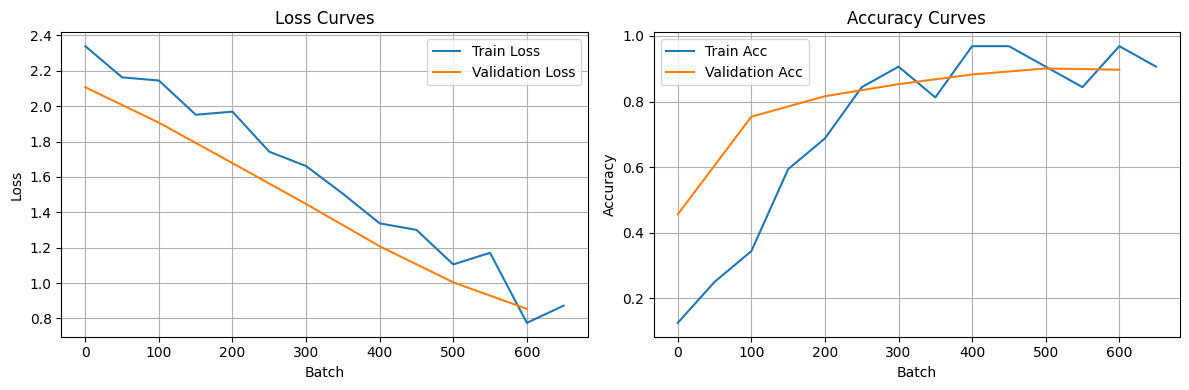

In [19]:
trainer.plot_curves(sample_step=50)
